# Iris dataset

In [5]:
from sklearn.datasets import load_iris

data = load_iris()

type(data)

sklearn.utils._bunch.Bunch

In [6]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
print(data["DESCR"])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# 150 samples, 4 features
data["data"].shape

(150, 4)

In [12]:
data["target"].shape

(150,)

In [32]:
# gör en df och konkatinerar
import pandas as pd

df = pd.DataFrame(data["data"])
df_target = pd.DataFrame(data["target"], columns=["target"])

df_iris = pd.concat([df, df_target], axis=1)

df_iris


,0,1,2,3,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


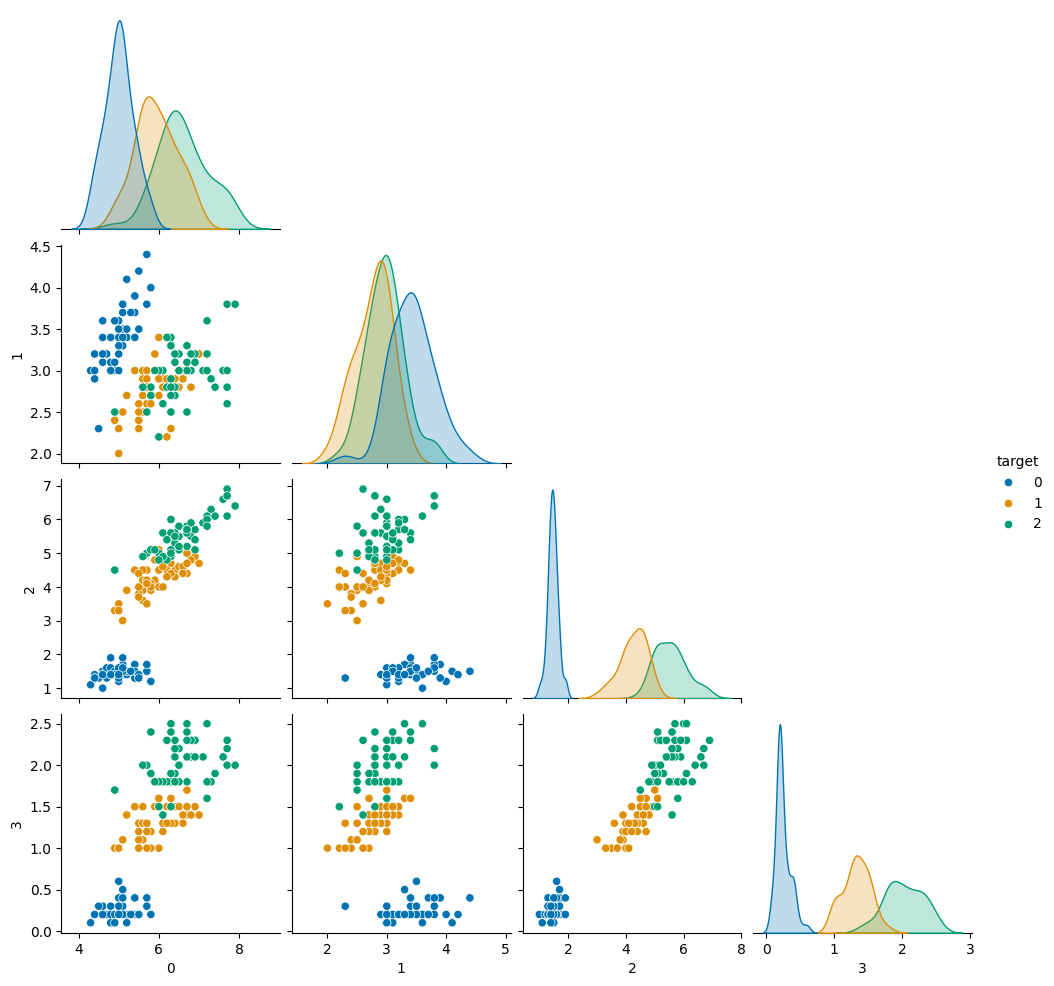

In [ ]:
import seaborn as sns
# Class 0 generally has shorter sepal length
# Class 0 generally has longest sepal width
# Class 0 generally petal length and width shortest


sns.pairplot(df_iris, corner=True, hue="target", palette="colorblind")

<Axes: >

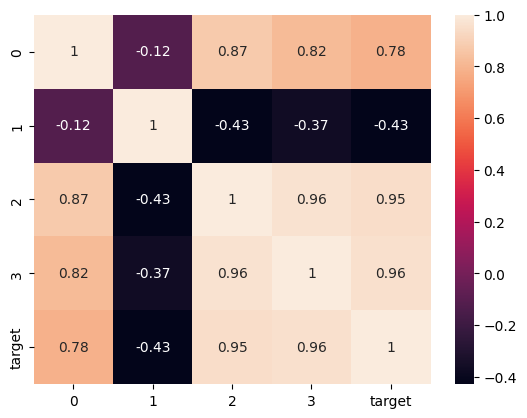

In [35]:
sns.heatmap(df_iris.corr(), annot=True)

<Axes: >

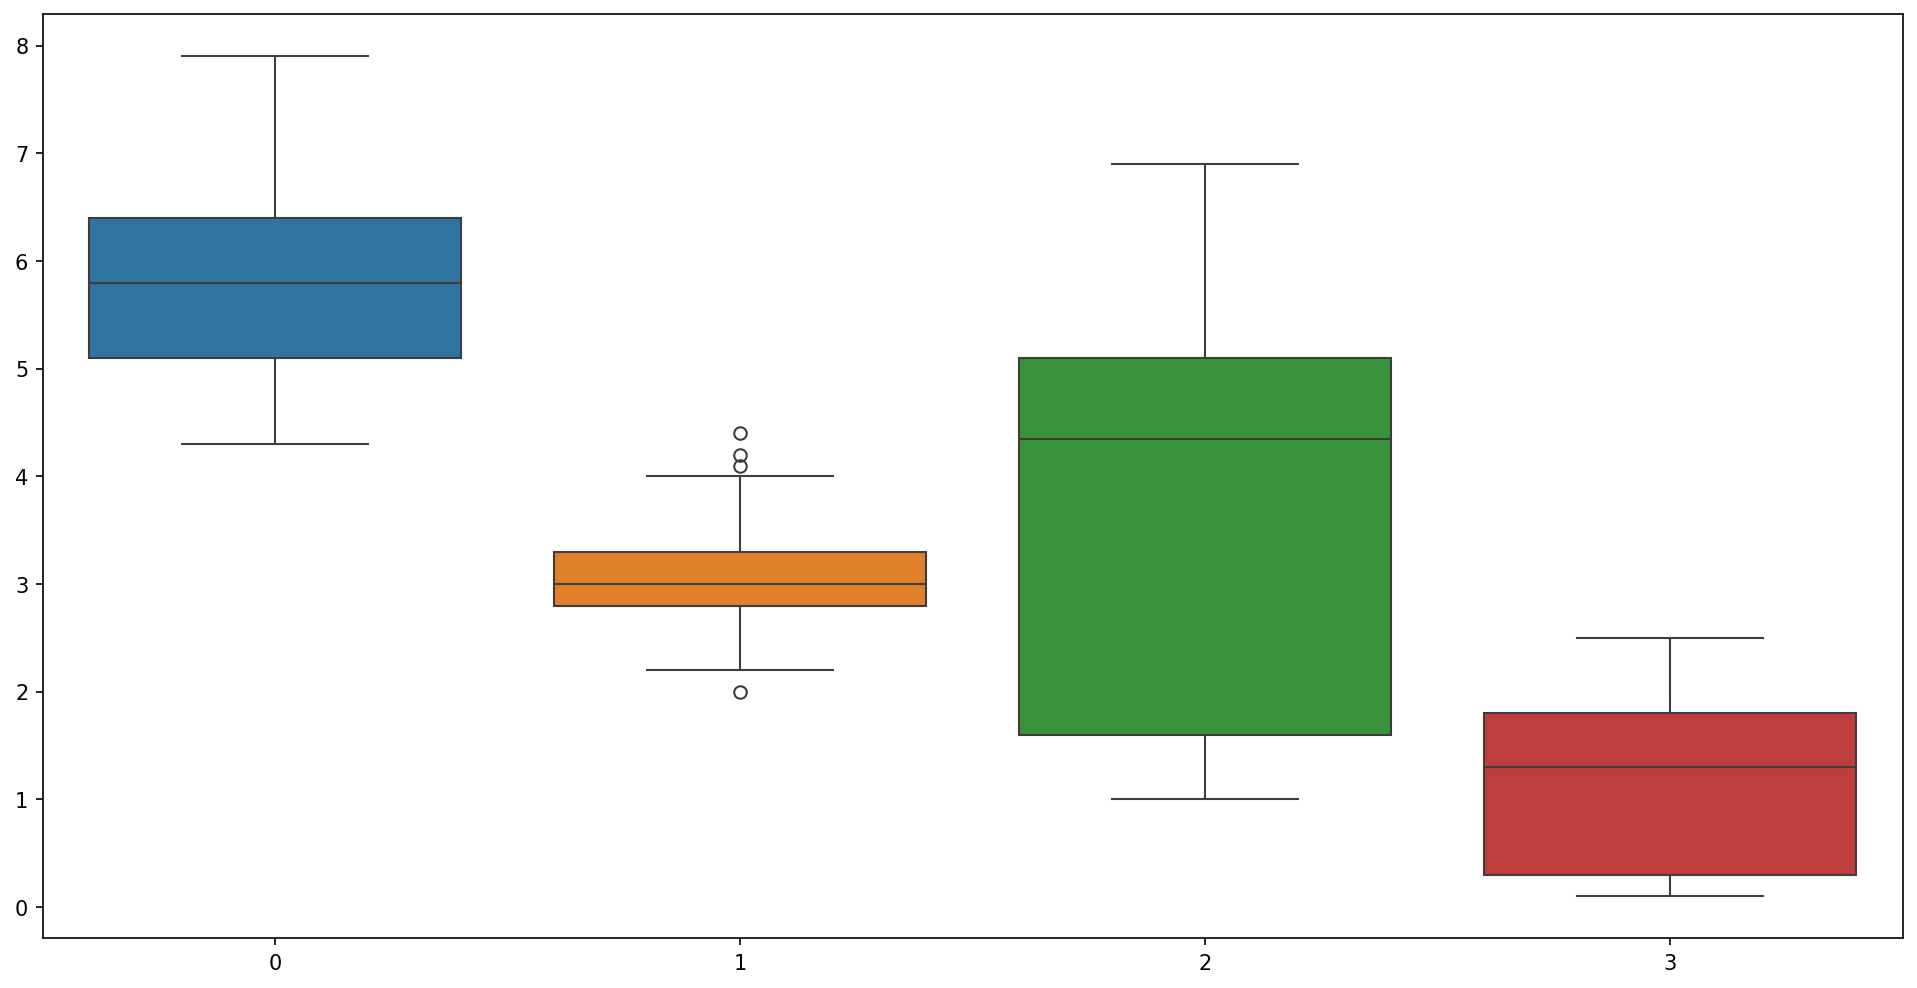

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(16,8), dpi=150)
sns.boxplot(df)



In [41]:
from sklearn.model_selection import train_test_split

X, y = df_iris.drop("target", axis=1), df_iris["target"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((100, 4), (50, 4))

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.mean(), scaled_X_train.std(), scaled_X_test.mean(), scaled_X_test.std()

(np.float64(-2.0788926136106057e-16),
 np.float64(0.9999999999999999),
 np.float64(0.0636657509197856),
 np.float64(1.0572097452539762))

In [54]:
# Classifying with Log regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)[:10]

In [53]:
y_test.iloc[:10].values

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



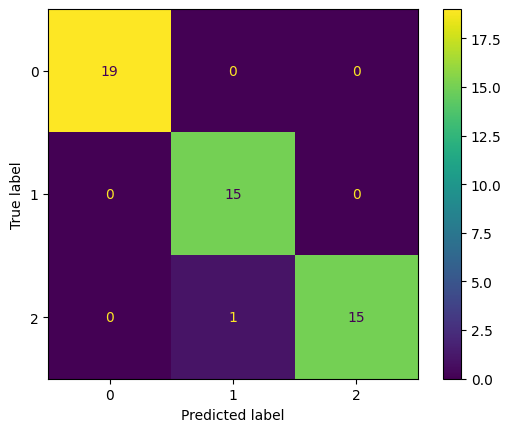

In [58]:
# evaluating
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(scaled_X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()